# Sesión conjunta · ¿Cuántas neuronas responden?
### L6 · viernes 18 de septiembre

Hoy calculamos, todos juntos, **la fracción de neuronas de su área que responden a las rejillas en
movimiento**. Es el único número que las once parejas van a calcular igual, y es el que vamos a
poner lado a lado el día de los pósters.

**Esto no es tarea.** Sale de esta sesión hecho. Pero debe incluirse en el notebook del proyecto final, y el resultado en el poster.

## Cómo se usa este notebook

Cada paso tiene dos celdas:

- Una **celda de texto con viñetas**: eso es lo que la celda de código tiene que hacer. Conviértanlo
  en un prompt, pídanle el código al modelo, péguenlo abajo y córranlo.
- Una **celda de código vacía**: ahí va lo que les devolvió, ya revisado.

Al final de cada paso hay una línea de **cómo saber si quedó bien**. Úsenla siempre. El modelo
escribe código que corre y da números equivocados sin avisar, y esa es la única defensa que tienen.

## Un consejo que les va a ahorrar tiempo

Cuando le pidan el código de los Pasos 2 en adelante, **péguenle primero la salida del paso 1**, la lista de variables del
archivo. Si el modelo no sabe cómo está hecho el archivo, se lo inventa: va a suponer nombres de
columnas que no existen y el código va a fallar o, peor, va a correr sobre lo que no es.

---
## Descargar los datos

Esta celda ya está escrita. Lo único que cambian es `MI_AREA`.

In [65]:
!pip install gdown -q
import numpy as np, gdown

# ---- Los ocho archivos. Cambien MI_AREA por la que les tocó en el sorteo. ----
IDS = {
    "VISp": "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut",    # 382 neuronas
    "VISl": "1GqceDf_3YPgPWAbDsIrjQySj4DRsd8Tw",    # 277 neuronas
    "VISal": "1TTyTRj92kbf7H6KE5-ah0DT7Ho2pV1pC",   # 481 neuronas
    "VISrl": "1n5XdMa5ZvRcKu7eTuI8latBQt5EHkLjJ",   # 308 neuronas
    "VISam": "1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO",   # 368 neuronas
    "VISpm": "1kL7fnRaB5tYVrNoabMGTqJzHnz8GWl_z",   # 296 neuronas
    "LGd": "1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_",     # 301 neuronas
    "LP": "1P7GMFi7u4cy_3AApazkyuovTKf4IFou0",      # 431 neuronas
}

MI_AREA = "LGd"        # <<<<<<<<<<  CAMBIEN ESTO

gdown.download(id=IDS[MI_AREA], output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print("\nÁrea:", MI_AREA, " ·  variables del archivo:")
print(d.files)

Downloading...
From (original): https://drive.google.com/uc?id=1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_
From (redirected): https://drive.google.com/uc?id=1ClWjSlBLWNbpVKKF3Kf5QpOwTtE0Wa2_&confirm=t&uuid=01b00cbd-4cb9-4b51-bb30-53c8c6ec9553
To: /content/datos.npz
100%|██████████| 34.9M/34.9M [00:00<00:00, 60.8MB/s]


Área: LGd  ·  variables del archivo:
['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## Configuración común del pipeline

Esta celda se ejecuta **una sola vez**, justo después de descargar los datos. Aquí se definen:

- los estilos de las figuras,
- las variables base del archivo,
- los índices de ensayos por clase (rejillas **sin** barridos en blanco, espontáneo),
- el umbral de respuesta,
- las funciones auxiliares de conteo.

Ninguna celda posterior vuelve a definir estas variables. Así el resultado no depende del orden en que se ejecuten las celdas.

**Ventanas de conteo del pipeline** (cada una tiene su propio nombre):

| Nombre | Ventana | Dónde se usa |
|---|---|---|
| `conteo_0a2s` / `tasa_0a2s_por_condicion` | 0 a 2 s fijo | Paso 3 (ejercicio de clase) |
| `conteo_dur` / `tasa_dur` | 0 a la duración real de cada ensayo (`e_dur`, ~2 s en rejillas y espontáneo) | Eje común, comparación 1 vs 15 Hz y demás análisis |

In [66]:
# ===================== CONFIGURACIÓN COMÚN DEL PIPELINE =====================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---- Estilo de todas las figuras (antes estaba al final del notebook) ----
plt.rcParams.update({
    "font.size": 14,          # tamaño base de todo el texto
    "axes.titlesize": 16,     # título del panel
    "axes.labelsize": 14,     # etiquetas de los ejes
    "xtick.labelsize": 12,    # números del eje X
    "ytick.labelsize": 12,    # números del eje Y
    "legend.fontsize": 12,    # texto de la leyenda
})

NOMBRE_AREA = MI_AREA

# ---- Variables base (una entrada por neurona / ensayo / espiga) ----
u_id = d["u_id"]
u_raton = d["u_raton"]
n_neuronas = len(u_id)

e_clase = d["e_clase"]
e_raton = d["e_raton"]
e_dur = d["e_dur"]                  # duración real de cada ensayo (s)
e_orientacion = d["e_orientacion"]  # en rejillas en movimiento = dirección
e_frec_temporal = d["e_frec_temporal"]
e_frec_espacial = d["e_frec_espacial"]

s_unidad = d["s_unidad"]   # ÍNDICE de la neurona en u_
s_ensayo = d["s_ensayo"]   # ÍNDICE del ensayo en e_
s_t = d["s_t"]             # s desde el inicio del estímulo

# ---- Índices de ensayos (se definen UNA sola vez) ----
idx_gratings_todos = np.where(e_clase == "drifting_gratings")[0]   # incluye barridos en blanco
es_blank = np.isnan(e_orientacion[idx_gratings_todos])
idx_gratings = idx_gratings_todos[~es_blank]                        # rejillas SIN blancos
idx_blank = idx_gratings_todos[es_blank]
idx_spont = np.where(e_clase == "spontaneous")[0]

# ---- Umbral de respuesta, único para todo el pipeline ----
umbral = 2.5

# ---- Funciones auxiliares de conteo ----
def armar_conteo(mask_espigas):
    """Cuenta PAs por (neurona, ensayo) usando solo las espigas donde mask_espigas es True."""
    df = pd.DataFrame({"unidad": s_unidad[mask_espigas], "ensayo": s_ensayo[mask_espigas]})
    return df.groupby(["unidad", "ensayo"]).size()

def ensayos_de_neurona(i, idx_ensayos):
    """De idx_ensayos, devuelve solo los que pertenecen al ratón de la neurona i."""
    return idx_ensayos[e_raton[idx_ensayos] == u_raton[i]]

def pas_de_neurona(i, trials_i, conteo):
    """Número de PAs de la neurona i en cada ensayo de trials_i (0 si no disparó)."""
    return conteo.reindex(
        pd.MultiIndex.from_product([[i], trials_i], names=["unidad", "ensayo"]),
        fill_value=0
    ).values

print(f"Área: {NOMBRE_AREA} | neuronas: {n_neuronas}")
print(f"Rejillas en movimiento: {len(idx_gratings_todos)} ensayos "
      f"({len(idx_gratings)} con rejilla + {len(idx_blank)} blancos)")
print(f"Espontáneo: {len(idx_spont)} ensayos | umbral de Z: {umbral}")

Área: LGd | neuronas: 301
Rejillas en movimiento: 2000 ensayos (1905 con rejilla + 95 blancos)
Espontáneo: 750 ensayos | umbral de Z: 2.5


---
## PASO 1 · Ver qué hay en el archivo

Lo que tiene que hacer la celda de abajo:

- Cuántas neuronas hay en total
- Cuántos ratones distintos (la columna u_raton)
- Cuántos ensayos hay de cada clase de estímulo (la columna e_clase)
- Cuántos PAs hay en total

> **Cómo saber si quedó bien.** El número de neuronas tiene que coincidir con el de la tabla del enunciado, y los ratones tienen que ser 5. Si no, están cargando el archivo equivocado.

In [67]:
print("neuronas:", len(d["u_id"]))
print("ratones:", np.unique(d["u_raton"]))
from collections import Counter
for clase, n in sorted(Counter(d["e_clase"]).items()):
  print(f" {clase:<20s} {n}")
print("espigas:", f"{len(d['s_t']):,}")

neuronas: 301
ratones: [715093703 750749662 756029989 760345702 761418226]
 drifting_gratings    2000
 flashes              750
 natural_movie_one    40
 natural_scenes       2000
 spontaneous          750
 static_gratings      1250
espigas: 9,075,182


---
## PASO 2 · Separar los ensayos que nos interesan

Lo que tiene que hacer la celda de abajo:

- Los índices de los ensayos cuya clase es drifting_gratings, que son las rejillas en movimiento
- Los índices de los ensayos cuya clase es spontaneous, que es la pantalla gris sin estímulo
- Imprimir cuántos hay de cada uno

> **Cómo saber si quedó bien.** Deben salir unos 2000 ensayos de rejillas y unos 750 de espontáneo, que son 400 y 150 por cada uno de los 5 ratones.

In [68]:
# Los índices ya se definieron en la configuración común; aquí solo se verifican.
# (idx_gratings_todos incluye los barridos en blanco; idx_gratings NO los incluye.)
print(f"Ensayos de rejillas en movimiento (con blancos): {len(idx_gratings_todos)}")
print(f"   de ellos, barridos en blanco: {len(idx_blank)}")
print(f"Ensayos de espontáneo: {len(idx_spont)}")

Ensayos de rejillas en movimiento (con blancos): 2000
   de ellos, barridos en blanco: 95
Ensayos de espontáneo: 750


---
## PASO 3 · La tasa de disparo de cada neurona en cada ensayo

Lo que tiene que hacer la celda de abajo:

- Para cada neurona y cada ensayo de rejilla, contar los PAs que caen entre 0 y 2 segundos y dividir por 2. Eso es la tasa evocada, en hercios
- Hacer lo mismo con los ensayos de espontáneo, también entre 0 y 2 segundos. Esa es la tasa basal
- Guardar las dos como matrices con una fila por neurona y una columna por ensayo
- Importante para el prompt: s_unidad dice a qué neurona pertenece cada PA y s_ensayo a qué ensayo, y los dos son ÍNDICES de las tablas u_ y e_, no identificadores
- Y esto también, o el resultado sale mal sin avisar: la tabla de ensayos trae los CINCO RATONES JUNTOS, y cada neurona solo vio los ensayos de SU ratón. Hay que emparejar u_raton con e_raton y quedarse, para cada neurona, solo con sus propias columnas

> **Cómo saber si quedó bien.** La tasa evocada mediana tiene que estar entre 1 y 30 Hz. Si les da 0, casi seguro no emparejaron los ratones: están promediando cada neurona sobre 2000 ensayos cuando solo vio 400, y los otros 1600 son ceros que no significan nada.

In [69]:
# PASO 3 (ejercicio de clase) · VENTANA FIJA 0 a 2 s
# Nombres con sufijo _0a2s para no confundirlos con la ventana de duración real (conteo_dur).
# Nota: aquí se usan todos los ensayos de rejillas, incluidos los blancos, como en la guía de clase.

mask_0a2s = (s_t >= 0) & (s_t <= 2)
conteo_0a2s = armar_conteo(mask_0a2s)

def tasa_0a2s_por_condicion(idx_ensayos_clase):
    """
    Matriz (neuronas x ensayos_por_raton) con la tasa en Hz en la ventana 0-2 s.
    Cada neurona usa solo los ensayos de SU ratón.
    """
    n_por_raton = pd.Series(e_raton[idx_ensayos_clase]).value_counts()
    n_ensayos = n_por_raton.iloc[0]
    assert (n_por_raton == n_ensayos).all(), "los ratones no tienen el mismo número de ensayos"

    tasa = np.zeros((n_neuronas, n_ensayos))
    for i in range(n_neuronas):
        trials_i = ensayos_de_neurona(i, idx_ensayos_clase)
        tasa[i] = pas_de_neurona(i, trials_i, conteo_0a2s) / 2.0   # ventana de 2 s -> Hz
    return tasa

tasa_evocada_0a2s = tasa_0a2s_por_condicion(idx_gratings_todos)   # neuronas x 400
tasa_basal_0a2s   = tasa_0a2s_por_condicion(idx_spont)            # neuronas x 150

print("tasa_evocada_0a2s shape:", tasa_evocada_0a2s.shape)
print("tasa_basal_0a2s shape:", tasa_basal_0a2s.shape)
print("mediana tasa evocada (Hz):", np.median(tasa_evocada_0a2s))
print("mediana tasa basal (Hz):", np.median(tasa_basal_0a2s))

tasa_evocada_0a2s shape: (301, 400)
tasa_basal_0a2s shape: (301, 150)
mediana tasa evocada (Hz): 7.5
mediana tasa basal (Hz): 7.5


In [70]:
import numpy as np
import pandas as pd

# Separar las claves del archivo por su prefijo (u_, e_, s_)
claves_u = [k for k in d.files if k.startswith("u_")]
claves_e = [k for k in d.files if k.startswith("e_")]
claves_s = [k for k in d.files if k.startswith("s_")]

def armar_tabla(claves, prefijo):
    columnas = {}
    for k in claves:
        arr = d[k]
        nombre = k.replace(prefijo, "")
        if arr.ndim == 1:
            columnas[nombre] = arr
        else:
            # variables multidimensionales (p. ej. u_onda, que trae varios
            # canales por neurona) no caben en una columna simple de la tabla
            print(f"(se omite '{k}' de la tabla: tiene forma {arr.shape}, no es 1D)")
    return pd.DataFrame(columnas)

tabla_neuronas = armar_tabla(claves_u, "u_") #la unica q tiene 1 neurona por fila
tabla_ensayos  = armar_tabla(claves_e, "e_")
tabla_espigas  = armar_tabla(claves_s, "s_")

print("Tabla de neuronas:", tabla_neuronas.shape)
display(tabla_neuronas.head())

print("\nTabla de ensayos:", tabla_ensayos.shape)
display(tabla_ensayos.head())

print("\nTabla de espigas:", tabla_espigas.shape)
display(tabla_espigas.head())

(se omite 'u_onda' de la tabla: tiene forma (301, 7, 82), no es 1D)
Tabla de neuronas: (301, 9)


,id,raton,canal,profundidad,snr,amplitude_cutoff,presence_ratio,isi_violations,firing_rate
0,951859617,750749662,850165130,100.0,2.212309,0.005132,0.99,0.065160,1.319713
1,951859660,750749662,850165158,240.0,1.192612,0.009291,0.99,0.231146,1.070324
2,951859683,750749662,850165164,280.0,2.714775,0.031025,0.97,0.354341,1.819197
3,951856382,750749662,850165164,280.0,3.888527,0.000304,0.98,0.014150,5.170456
4,951856084,750749662,850165134,120.0,1.243324,0.023017,0.99,0.114490,5.011094



Tabla de ensayos: (6790, 10)


,clase,raton,t0,dur,orientacion,frec_temporal,frec_espacial,contraste,color,imagen
0,drifting_gratings,750749662,1585.570019,2.00165,135.0,2.0,0.04,0.8,NaN,NaN
1,drifting_gratings,750749662,1588.572502,2.00168,45.0,4.0,0.04,0.8,NaN,NaN
2,drifting_gratings,750749662,1591.575029,2.00169,45.0,1.0,0.04,0.8,NaN,NaN
3,drifting_gratings,750749662,1594.577522,2.00168,90.0,1.0,0.04,0.8,NaN,NaN
4,drifting_gratings,750749662,1603.585079,2.00167,180.0,1.0,0.04,0.8,NaN,NaN



Tabla de espigas: (9075182, 3)


,unidad,ensayo,t
0,0,958,1.105580
1,0,959,0.569279
2,0,959,0.573212
3,0,959,1.437844
4,0,960,0.697543


In [71]:
from IPython.display import Markdown, display

#La verdad opino que se ve mejor la tabla y la entoendo mejor sin markdown

def resumen_markdown(tabla, nombre):
    texto = f"## Resumen: {nombre}\n\n"
    texto += f"- **Filas:** {tabla.shape[0]:,}\n"

    texto += "| Columna | Tipo | Únicos | Nulos | Ejemplo |\n"
    texto += "|---|---|---|---|---|\n"
    for col in tabla.columns:
        dtype = tabla[col].dtype
        n_unicos = tabla[col].nunique()
        n_nulos = tabla[col].isna().sum()
        ejemplo = tabla[col].dropna().iloc[0] if tabla[col].notna().any() else "—"
        texto += f"| `{col}` | {dtype} | {n_unicos:,} | {n_nulos:,} | {ejemplo} |\n"

    return texto

# Genera el resumen para cada tabla y lo muestra formateado
display(Markdown(resumen_markdown(tabla_neuronas, "Neuronas (u_)")))
display(Markdown(resumen_markdown(tabla_ensayos, "Ensayos (e_)")))
display(Markdown(resumen_markdown(tabla_espigas, "Espigas (s_)")))

## Resumen: Neuronas (u_)

- **Filas:** 301
| Columna | Tipo | Únicos | Nulos | Ejemplo |
|---|---|---|---|---|
| `id` | int64 | 301 | 0 | 951859617 |
| `raton` | int64 | 5 | 0 | 750749662 |
| `canal` | int64 | 174 | 0 | 850165130 |
| `profundidad` | float32 | 60 | 0 | 100.0 |
| `snr` | float64 | 301 | 0 | 2.21230918083181 |
| `amplitude_cutoff` | float64 | 301 | 0 | 0.00513216744337807 |
| `presence_ratio` | float64 | 6 | 0 | 0.99 |
| `isi_violations` | float64 | 287 | 0 | 0.0651600022042669 |
| `firing_rate` | float64 | 301 | 0 | 1.31971279472757 |


## Resumen: Ensayos (e_)

- **Filas:** 6,790
| Columna | Tipo | Únicos | Nulos | Ejemplo |
|---|---|---|---|---|
| `clase` | object | 6 | 0 | drifting_gratings |
| `raton` | int64 | 5 | 0 | 750749662 |
| `t0` | float64 | 6,790 | 0 | 1585.570018924872 |
| `dur` | float32 | 158 | 0 | 2.001650094985962 |
| `orientacion` | float32 | 12 | 2,925 | 135.0 |
| `frec_temporal` | float32 | 5 | 4,885 | 2.0 |
| `frec_espacial` | float32 | 5 | 3,675 | 0.03999999910593033 |
| `contraste` | float32 | 1 | 2,925 | 0.800000011920929 |
| `color` | float32 | 2 | 6,040 | -1.0 |
| `imagen` | float32 | 119 | 4,790 | 26.0 |


## Resumen: Espigas (s_)

- **Filas:** 9,075,182
| Columna | Tipo | Únicos | Nulos | Ejemplo |
|---|---|---|---|---|
| `unidad` | int32 | 301 | 0 | 0 |
| `ensayo` | int32 | 6,785 | 0 | 958 |
| `t` | float32 | 8,370,235 | 0 | 1.105580449104309 |



--
## PASO 4 · ¿Cuáles responden?

Lo que tiene que hacer la celda de abajo:

- Para cada neurona, el Z-score: la tasa evocada promedio menos la basal promedio, dividido por la desviación estándar de su propia basal. Todo calculado solo sobre los ensayos de su ratón
- Calcula la respuesta evocada para cada una de las combinaciones de caracteristica de estímulo posibles (direcciones, frecuencias temporales, frecuencias espaciales).
- Identifica la combinación que genera la tasa de disparo máxima (condición preferida) para cada neurona y calcula el z-score usando solo los ensayos de esta combinación.
- Contar cuántas neuronas tienen un Z-score de 2,5 o más
- La fracción respondedora es ese número dividido por el total de neuronas
- Imprimir la fracción como porcentaje

> **Cómo saber si quedó bien.** Si les da 0 % o más del 95 %, revisen el paso 3 antes de seguir: casi siempre es que no emparejaron los ratones. Cualquier cosa entre esos dos extremos es un resultado, no un error. En VISp, con umbral 2,5, da alrededor del 13 % si combinan todas las características del estímulo.

In [72]:
# PASO 4 · EJE COMÚN DEL CURSO (número oficial del póster)
# Z-score con la COMBINACIÓN PREFERIDA de cada neurona (dirección x frec. temporal x frec. espacial),
# como exige el enunciado. Ventana: duración real de cada ensayo (conteo_dur).

# ---- Conteo con ventana de duración real: 0 a e_dur de cada ensayo ----
mask_dur = (s_t >= 0) & (s_t <= e_dur[s_ensayo])
conteo_dur = armar_conteo(mask_dur)

def tasa_dur(i, idx_ensayos):
    """Tasa (Hz) de la neurona i en sus ensayos de idx_ensayos, ventana 0 a e_dur."""
    trials_i = ensayos_de_neurona(i, idx_ensayos)
    return trials_i, pas_de_neurona(i, trials_i, conteo_dur) / e_dur[trials_i]

# ---- Z-score por combinación; nos quedamos con la máxima (condición preferida) ----
zscore_preferido = np.full(n_neuronas, np.nan)
pref_direccion = np.full(n_neuronas, np.nan)       # se guardan para el raster
pref_frec_temporal = np.full(n_neuronas, np.nan)   # y para el histograma del punto extra
pref_frec_espacial = np.full(n_neuronas, np.nan)

for i in range(n_neuronas):
    _, tasa_basal_i = tasa_dur(i, idx_spont)
    basal_media = tasa_basal_i.mean()
    basal_std = tasa_basal_i.std(ddof=1)
    if basal_std == 0:
        continue

    trials_i, tasa_grat_i = tasa_dur(i, idx_gratings)
    combo = pd.DataFrame({
        "direccion": e_orientacion[trials_i],
        "frec_temporal": e_frec_temporal[trials_i],
        "frec_espacial": e_frec_espacial[trials_i],
        "tasa": tasa_grat_i
    })
    medias_por_combo = combo.groupby(["direccion", "frec_temporal", "frec_espacial"])["tasa"].mean()
    zscores_por_combo = (medias_por_combo - basal_media) / basal_std

    zscore_preferido[i] = zscores_por_combo.max()
    pref_direccion[i], pref_frec_temporal[i], pref_frec_espacial[i] = zscores_por_combo.idxmax()

# ---- Resultado oficial del eje común ----
zscore_eje_comun = zscore_preferido
calculadas_eje_comun = ~np.isnan(zscore_eje_comun)
n_eje_comun = calculadas_eje_comun.sum()
respondedoras_eje_comun = np.sum(zscore_eje_comun[calculadas_eje_comun] >= umbral)
fraccion_eje_comun = respondedoras_eje_comun / n_eje_comun

print("[Eje común del curso] Rejillas en movimiento vs espontáneo, condición preferida")
print(f"Responden {respondedoras_eje_comun} de {n_eje_comun} neuronas (umbral Z >= {umbral})")
print(f"Fracción respondedora: {fraccion_eje_comun*100:.1f}%")

[Eje común del curso] Rejillas en movimiento vs espontáneo, condición preferida
Responden 35 de 301 neuronas (umbral Z >= 2.5)
Fracción respondedora: 11.6%


---
## PASO 5 · La misma cuenta, ratón por ratón

Lo que tiene que hacer la celda de abajo:

- Repetir el paso 4 pero por separado para las neuronas de cada ratón, usando la columna u_raton
- Imprimir las cinco fracciones, con el número de neuronas de cada ratón


> **Cómo saber si quedó bien.** Las cinco se van a parecer pero no van a ser iguales. Esa diferencia entre animales es exactamente la razón por la que el bootstrap tiene que tener el nivel de ratón.

In [73]:
import numpy as np
import pandas as pd

# Usa el zscore_preferido ya calculado (paso 4), agrupado por ratón
df_por_raton = pd.DataFrame({
    "raton": u_raton,
    "zscore_preferido": zscore_preferido
})

print(f"Umbral de Z-score: {umbral}\n")

resultados_por_raton = []

for raton_id, grupo in df_por_raton.groupby("raton"):
    calculadas = grupo["zscore_preferido"].notna()
    n_calculadas = calculadas.sum()
    respondedoras = (grupo.loc[calculadas, "zscore_preferido"] >= umbral).sum()
    fraccion = respondedoras / n_calculadas

    resultados_por_raton.append({
        "raton": raton_id,
        "n_neuronas": n_calculadas,
        "respondedoras": respondedoras,
        "fraccion": fraccion
    })

    print(f"Ratón {raton_id}: responden {respondedoras} de {n_calculadas} neuronas "
          f"({fraccion*100:.1f}%)")

df_resumen_ratones = pd.DataFrame(resultados_por_raton)
print("\n--- Resumen ---")
display(df_resumen_ratones)

Umbral de Z-score: 2.5

Ratón 715093703: responden 25 de 82 neuronas (30.5%)
Ratón 750749662: responden 4 de 82 neuronas (4.9%)
Ratón 756029989: responden 4 de 59 neuronas (6.8%)
Ratón 760345702: responden 2 de 37 neuronas (5.4%)
Ratón 761418226: responden 0 de 41 neuronas (0.0%)

--- Resumen ---


,raton,n_neuronas,respondedoras,fraccion
0,715093703,82,25,0.304878
1,750749662,82,4,0.048780
2,756029989,59,4,0.067797
3,760345702,37,2,0.054054
4,761418226,41,0,0.000000


---
## PASO 6 · La gráfica

Lo que tiene que hacer la celda de abajo:

- Un punto por ratón con su fracción respondedora
- Una línea horizontal con la fracción del conjunto de las neuronas
- Ejes rotulados y el número del conjunto escrito dentro de la figura
- Título con el nombre del área

> **Cómo saber si quedó bien.** Variación pequeña de cada ratón.

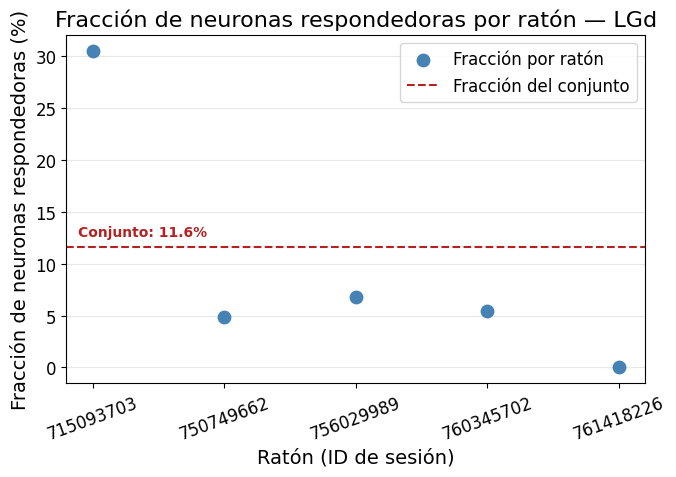

In [74]:
import matplotlib.pyplot as plt

nombre_area = NOMBRE_AREA

calculadas_global = ~np.isnan(zscore_preferido)
respondedoras_global = np.sum(zscore_preferido[calculadas_global] >= umbral)
fraccion_global = respondedoras_global / calculadas_global.sum()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df_resumen_ratones["raton"].astype(str),
    df_resumen_ratones["fraccion"] * 100,
    s=80,
    color="steelblue",
    zorder=3,
    label="Fracción por ratón"
)

ax.axhline(
    fraccion_global * 100,
    color="firebrick",
    linestyle="--",
    linewidth=1.5,
    zorder=2,
    label="Fracción del conjunto"
)

ax.text(
    0.02, fraccion_global * 100 + 1,
    f"Conjunto: {fraccion_global*100:.1f}%",
    transform=ax.get_yaxis_transform(),
    color="firebrick",
    fontsize=10,
    fontweight="bold"
)

ax.set_xlabel("Ratón (ID de sesión)")
ax.set_ylabel("Fracción de neuronas respondedoras (%)")
ax.set_title(f"Fracción de neuronas respondedoras por ratón — {nombre_area}")

ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

---
## Para cerrar

Anoten su número: **la fracción de neuronas de su área que responden a las rejillas en movimiento**.

Ese número va al póster y es el que comparamos entre las once parejas el viernes 25. Puestos en
orden de área, los once juntos reconstruyen la jerarquía visual del ratón.

Guarden este notebook en su repositorio de GitHub. Es la primera pieza del pipeline del proyecto.

---
## Comparación metodológica: Z sin desglosar por combinación

**Esta NO es la fracción del eje común.** El número oficial (el del póster y del panel 2A) es el del **Paso 4**, calculado con la condición preferida de cada neurona, como pide el enunciado.

Aquí se calcula la misma fracción promediando **todos** los ensayos de rejillas, sin elegir la condición preferida. Sirve para mostrar en métodos cuánto se diluye la respuesta al promediar condiciones a las que la neurona no responde. Ambos cálculos usan la misma ventana (`conteo_dur`) y el mismo umbral.

In [75]:
# Z-score SIN desglosar: promedio sobre TODOS los ensayos de rejillas (todas las combinaciones).
# Misma ventana (tasa_dur) y mismo umbral que el eje común; solo cambia el criterio.
zscore_sin_desglosar = np.full(n_neuronas, np.nan)

for i in range(n_neuronas):
    _, tasa_basal_i = tasa_dur(i, idx_spont)
    basal_media = tasa_basal_i.mean()
    basal_std = tasa_basal_i.std(ddof=1)
    if basal_std == 0:
        continue
    _, tasa_evocada_i = tasa_dur(i, idx_gratings)
    zscore_sin_desglosar[i] = (tasa_evocada_i.mean() - basal_media) / basal_std

calc = ~np.isnan(zscore_sin_desglosar)
respondedoras_sin_desglosar = np.sum(zscore_sin_desglosar[calc] >= umbral)
fraccion_sin_desglosar = respondedoras_sin_desglosar / calc.sum()

print(f"Condición preferida (eje común oficial): {respondedoras_eje_comun}/{n_eje_comun} "
      f"({fraccion_eje_comun*100:.1f}%)")
print(f"Sin desglosar (solo comparación):        {respondedoras_sin_desglosar}/{calc.sum()} "
      f"({fraccion_sin_desglosar*100:.1f}%)")

Condición preferida (eje común oficial): 35/301 (11.6%)
Sin desglosar (solo comparación):        6/301 (2.0%)


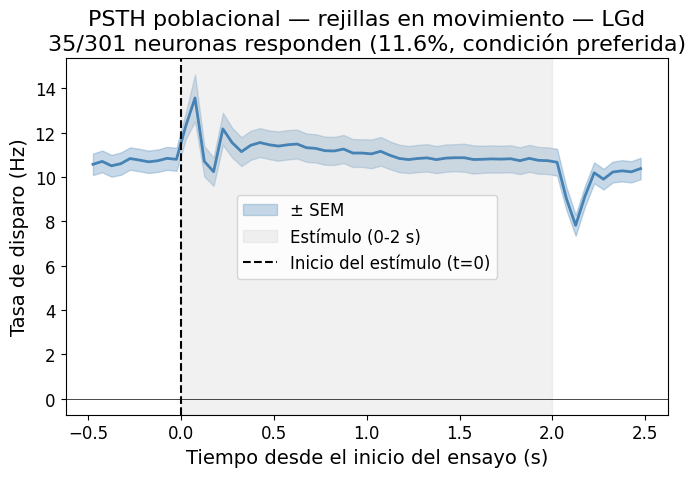

In [76]:
# PANEL 2A · usa idx_gratings (sin blancos) de la configuración común
import matplotlib.pyplot as plt

# --- PSTH poblacional para rejillas en movimiento ---
bin_size = 0.05  # 50 ms por bin, ajustable
t_min, t_max = -0.5, 2.5  # ventana de tiempo a graficar (ajusta según tu raster)
bins = np.arange(t_min, t_max + bin_size, bin_size)
centros_bins = bins[:-1] + bin_size / 2

# Para cada neurona, su PSTH promedio sobre SUS ensayos de rejillas (de su ratón)
psth_por_neurona = np.full((n_neuronas, len(centros_bins)), np.nan)

for i in range(n_neuronas):
    raton_i = u_raton[i]
    trials_i = idx_gratings[e_raton[idx_gratings] == raton_i]

    # todas las espigas de esta neurona en estos ensayos, dentro de la ventana
    mask_i = (s_unidad == i) & np.isin(s_ensayo, trials_i)
    spikes_i = s_t[mask_i]

    # histograma de espigas por bin, sumado sobre TODOS los ensayos de esta neurona
    conteo_bins, _ = np.histogram(spikes_i, bins=bins)

    # tasa en Hz: conteo dividido por (n_ensayos x bin_size)
    psth_por_neurona[i] = conteo_bins / (len(trials_i) * bin_size)

# Promedio y error estándar sobre neuronas
psth_media = np.nanmean(psth_por_neurona, axis=0)
psth_sem = np.nanstd(psth_por_neurona, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(psth_por_neurona[:, 0])))

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(centros_bins, psth_media, color="steelblue", linewidth=2)
ax.fill_between(centros_bins, psth_media - psth_sem, psth_media + psth_sem,
                 color="steelblue", alpha=0.3, label="± SEM")

ax.axvspan(0, 2, color="lightgray", alpha=0.3, label="Estímulo (0-2 s)")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Inicio del estímulo (t=0)")
ax.axhline(0, color="black", linewidth=0.5)

ax.set_xlabel("Tiempo desde el inicio del ensayo (s)")
ax.set_ylabel("Tasa de disparo (Hz)")
ax.set_title(f"PSTH poblacional — rejillas en movimiento — {NOMBRE_AREA}\n"
             f"{respondedoras_eje_comun}/{n_eje_comun} neuronas responden ({fraccion_eje_comun*100:.1f}%, condición preferida)")
ax.legend()
plt.tight_layout()
plt.show()

## Comparación asignada: frecuencia temporal 1 Hz vs 15 Hz

**Ventana:** la misma del eje común (`tasa_dur`, 0 a la duración real del ensayo, ~2 s). La ventana anterior de 0,5 s tenía un problema: a 1 Hz cubre solo medio ciclo de la rejilla, mientras que a 15 Hz cubre 7,5 ciclos, así que la comparación favorecía a 15 Hz. Con 2 s, la rejilla de 1 Hz completa 2 ciclos.

**Criterio:** para ser coherentes con el eje común, cada neurona se evalúa en su **dirección preferida dentro de cada frecuencia**, en lugar de promediar las 8 direcciones. El máximo se toma sobre 8 direcciones en ambas condiciones, así que el sesgo que introduce elegir el máximo es el mismo en las dos.

In [77]:
# Ensayos de 1 Hz y de 15 Hz (sin blancos; frecuencia espacial fija en 0,04 cpd)
idx_1hz = idx_gratings[e_frec_temporal[idx_gratings] == 1.0]
idx_15hz = idx_gratings[e_frec_temporal[idx_gratings] == 15.0]

def z_direccion_preferida(i, idx_condicion, basal_media, basal_std):
    """Z de la neurona i en su dirección preferida dentro de idx_condicion (ventana tasa_dur)."""
    trials_i, tasa_i = tasa_dur(i, idx_condicion)
    medias_por_dir = pd.Series(tasa_i).groupby(e_orientacion[trials_i]).mean()
    z_por_dir = (medias_por_dir - basal_media) / basal_std
    return z_por_dir.max(), z_por_dir.idxmax()

z_1hz = np.full(n_neuronas, np.nan)
z_15hz = np.full(n_neuronas, np.nan)
dir_pref_1hz = np.full(n_neuronas, np.nan)
dir_pref_15hz = np.full(n_neuronas, np.nan)

for i in range(n_neuronas):
    _, tasa_basal_i = tasa_dur(i, idx_spont)
    basal_media = tasa_basal_i.mean()
    basal_std = tasa_basal_i.std(ddof=1)
    if basal_std == 0:
        continue
    z_1hz[i], dir_pref_1hz[i] = z_direccion_preferida(i, idx_1hz, basal_media, basal_std)
    z_15hz[i], dir_pref_15hz[i] = z_direccion_preferida(i, idx_15hz, basal_media, basal_std)

# ---- Fracción respondedora en cada condición ----
calc_1hz = ~np.isnan(z_1hz)
calc_15hz = ~np.isnan(z_15hz)
resp_1hz = np.sum(z_1hz[calc_1hz] >= umbral)
resp_15hz = np.sum(z_15hz[calc_15hz] >= umbral)
frac_1hz = resp_1hz / calc_1hz.sum()
frac_15hz = resp_15hz / calc_15hz.sum()

print(f"Ensayos de 1 Hz: {len(idx_1hz)} | Ensayos de 15 Hz: {len(idx_15hz)}\n")
print(f"1 Hz  -> responden {resp_1hz} de {calc_1hz.sum()} neuronas ({frac_1hz*100:.1f}%)")
print(f"15 Hz -> responden {resp_15hz} de {calc_15hz.sum()} neuronas ({frac_15hz*100:.1f}%)")

resumen_comparacion = pd.DataFrame({
    "neurona": np.arange(n_neuronas),
    "raton": u_raton,
    "z_1hz": z_1hz,
    "z_15hz": z_15hz,
    "dir_pref_1hz": dir_pref_1hz,
    "dir_pref_15hz": dir_pref_15hz,
    "responde_1hz": z_1hz >= umbral,
    "responde_15hz": z_15hz >= umbral,
})
display(resumen_comparacion.head(10))

Ensayos de 1 Hz: 380 | Ensayos de 15 Hz: 385

1 Hz  -> responden 14 de 301 neuronas (4.7%)
15 Hz -> responden 18 de 301 neuronas (6.0%)


,neurona,raton,z_1hz,z_15hz,dir_pref_1hz,dir_pref_15hz,responde_1hz,responde_15hz
0,0,750749662,0.631162,0.489294,45.0,90.0,False,False
1,1,750749662,0.360330,0.464823,45.0,45.0,False,False
2,2,750749662,0.269521,0.053166,270.0,135.0,False,False
3,3,750749662,5.088331,1.938649,0.0,315.0,True,False
4,4,750749662,0.111343,0.830415,180.0,135.0,False,False
5,5,750749662,0.234568,0.601019,90.0,315.0,False,False
6,6,750749662,-0.263236,0.543033,90.0,45.0,False,False
7,7,750749662,0.794560,0.490336,180.0,315.0,False,False
8,8,750749662,0.077909,0.077912,90.0,45.0,False,False
9,9,750749662,1.001928,0.937410,180.0,45.0,False,False


In [78]:
# ¿Cuánto se solapan las neuronas que responden a 1Hz vs 15Hz?
resp_1hz_ids = set(resumen_comparacion[resumen_comparacion["responde_1hz"]]["neurona"])
resp_15hz_ids = set(resumen_comparacion[resumen_comparacion["responde_15hz"]]["neurona"])

print(f"Neuronas que responden SOLO a 1 Hz: {resp_1hz_ids - resp_15hz_ids}")
print(f"Neuronas que responden SOLO a 15 Hz: {resp_15hz_ids - resp_1hz_ids}")
print(f"Neuronas que responden a AMBAS: {resp_1hz_ids & resp_15hz_ids}")

Neuronas que responden SOLO a 1 Hz: {3, 109, 117, 118, 121, 94}
Neuronas que responden SOLO a 15 Hz: {97, 193, 35, 138, 171, 267, 111, 207, 125, 127}
Neuronas que responden a AMBAS: {98, 290, 143, 47, 82, 83, 116, 219}


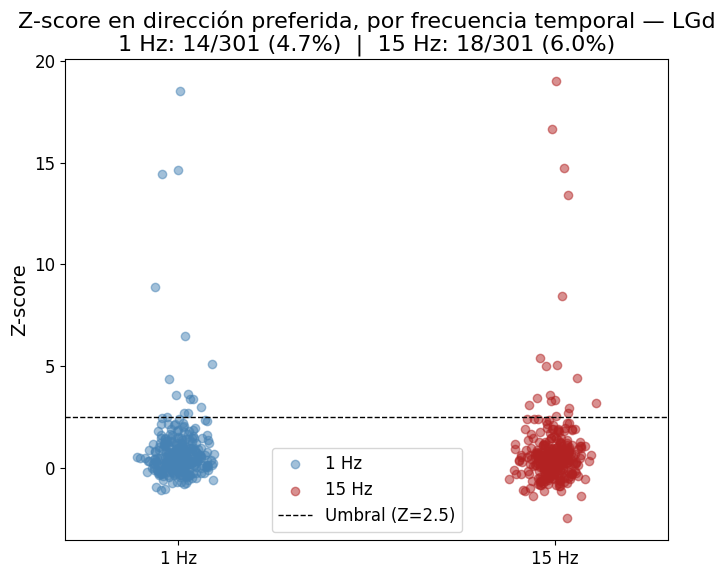

In [79]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 6))

# Jitter horizontal para que los puntos no se amontonen en una sola línea
np.random.seed(0)
x_1hz = np.random.normal(0, 0.04, n_neuronas)
x_15hz = np.random.normal(1, 0.04, n_neuronas)

ax.scatter(x_1hz, z_1hz, alpha=0.5, color="steelblue", label="1 Hz")
ax.scatter(x_15hz, z_15hz, alpha=0.5, color="firebrick", label="15 Hz")

ax.axhline(umbral, color="black", linestyle="--", linewidth=1,
           label=f"Umbral (Z={umbral})")

ax.set_xticks([0, 1])
ax.set_xticklabels(["1 Hz", "15 Hz"])
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel("Z-score")
ax.set_title(f"Z-score en dirección preferida, por frecuencia temporal — {NOMBRE_AREA}\n"
             f"1 Hz: {resp_1hz}/{calc_1hz.sum()} ({frac_1hz*100:.1f}%)  |  "
             f"15 Hz: {resp_15hz}/{calc_15hz.sum()} ({frac_15hz*100:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()

In [80]:
# panel c
import numpy as np
import matplotlib.pyplot as plt

neurona_ejemplo = 98
u_onda = d["u_onda"]

print(f"Forma de u_onda: {u_onda.shape}")  # para confirmar el orden de los ejes

onda_neurona = u_onda[neurona_ejemplo]  # (canales, muestras) o (muestras, canales), según el archivo
print(f"Forma de la onda de la neurona {neurona_ejemplo}: {onda_neurona.shape}")

Forma de u_onda: (301, 7, 82)
Forma de la onda de la neurona 98: (7, 82)


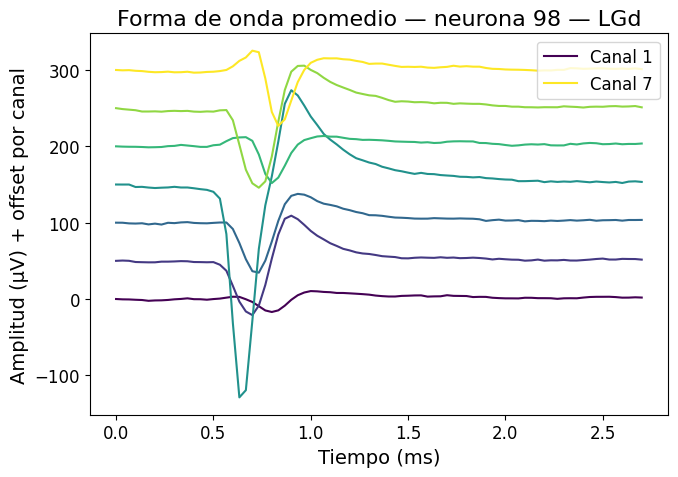

In [81]:
fig, ax = plt.subplots(figsize=(7, 5))

n_canales = onda_neurona.shape[0]
colores = plt.cm.viridis(np.linspace(0, 1, n_canales))

for c in range(n_canales):
    offset = c * 50  # separación vertical entre canales, en µV, ajusta si se solapan o quedan muy separados
    t_ms = np.arange(onda_neurona.shape[1]) / 30.0   # 30 kHz -> ms
    ax.plot(t_ms, onda_neurona[c] + offset, color=colores[c], linewidth=1.5,
        label=f"Canal {c+1}" if c in [0, n_canales-1] else None)

ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Amplitud (µV) + offset por canal")
ax.set_title(f"Forma de onda promedio — neurona {neurona_ejemplo} — {NOMBRE_AREA}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

---
## Figura 1D · Raster y PSTH de la neurona ejemplo

Una columna por condición asignada (1 Hz y 15 Hz).

- **Raster (arriba):** todos los ensayos de esa frecuencia del ratón de la neurona, agrupados por dirección. La banda de color marca la dirección preferida en esa frecuencia.
- **PSTH (abajo):** tasa en bins de 50 ms, promediada sobre los ensayos de la dirección preferida (color) y sobre todas las direcciones (gris), con sombreado de error estándar entre ensayos. La línea discontinua es la tasa basal media en espontáneo.

La franja gris marca el estímulo (0 a 2 s).

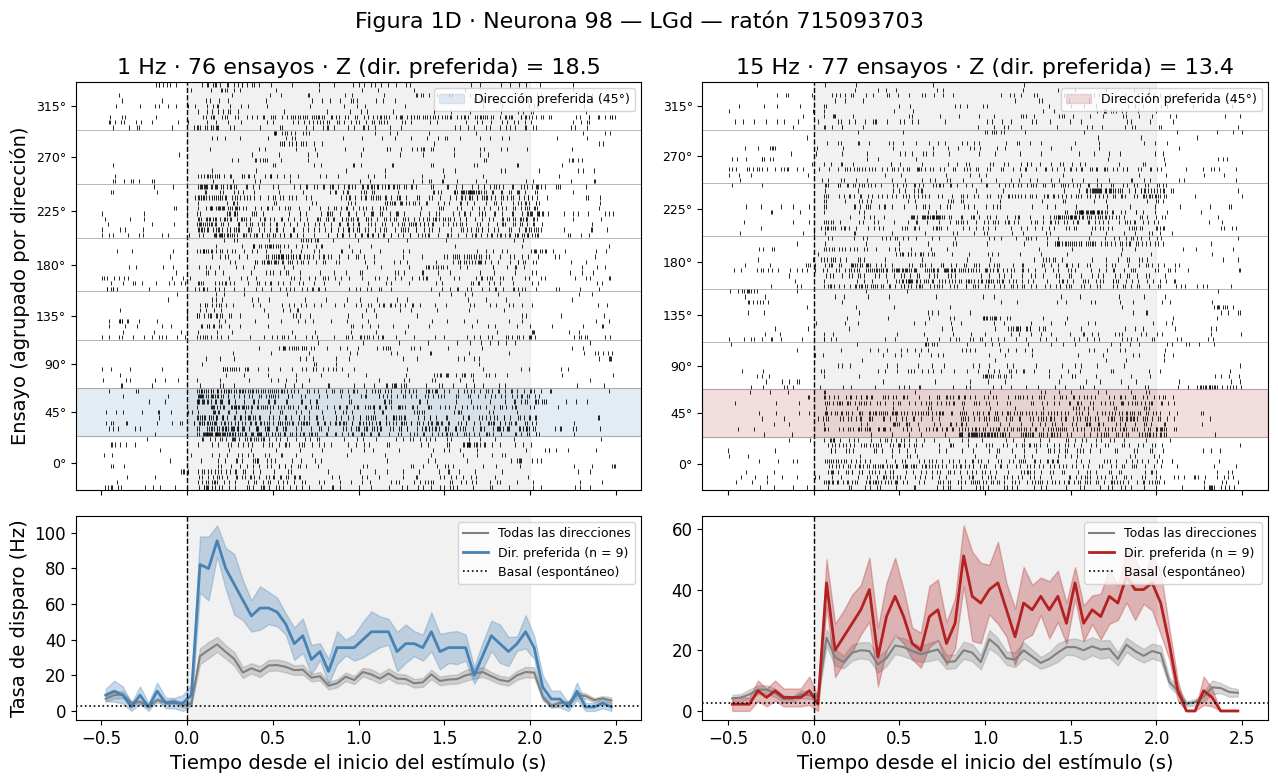

In [82]:
# ======================= FIGURA 1D · RASTER + PSTH =======================
neurona_ejemplo = 98          # misma neurona que la forma de onda (panel 1C)
BIN_1D = 0.05                 # 50 ms por bin
T_MIN_1D, T_MAX_1D = -0.5, 2.5
bins_1d = np.arange(T_MIN_1D, T_MAX_1D + BIN_1D / 2, BIN_1D)
centros_1d = bins_1d[:-1] + BIN_1D / 2

# Espigas de esta neurona, extraídas UNA vez (evita recorrer millones de espigas por ensayo)
mask_n = s_unidad == neurona_ejemplo
t_n, ens_n = s_t[mask_n], s_ensayo[mask_n]

def espigas_por_ensayo(trials):
    """Lista con los tiempos de espiga de la neurona ejemplo en cada ensayo de trials."""
    return [t_n[ens_n == tr] for tr in trials]

def psth_con_sem(lista_espigas):
    """PSTH (Hz) promediado sobre ensayos y su error estándar entre ensayos."""
    h = np.array([np.histogram(e, bins=bins_1d)[0] / BIN_1D for e in lista_espigas])
    sem = h.std(axis=0, ddof=1) / np.sqrt(len(h)) if len(h) > 1 else np.zeros(h.shape[1])
    return h.mean(axis=0), sem

# Tasa basal media de la neurona (espontáneo, misma ventana tasa_dur)
_, tasa_basal_n = tasa_dur(neurona_ejemplo, idx_spont)
basal_n = tasa_basal_n.mean()

condiciones_1d = [
    ("1 Hz",  idx_1hz,  dir_pref_1hz[neurona_ejemplo],  z_1hz[neurona_ejemplo],  "steelblue"),
    ("15 Hz", idx_15hz, dir_pref_15hz[neurona_ejemplo], z_15hz[neurona_ejemplo], "firebrick"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

for col, (etiqueta, idx_cond, dir_pref, z, color) in enumerate(condiciones_1d):
    # Ensayos de esta frecuencia, solo del ratón de la neurona, ordenados por dirección
    trials = ensayos_de_neurona(neurona_ejemplo, idx_cond)
    trials = trials[np.argsort(e_orientacion[trials], kind="stable")]
    dirs = e_orientacion[trials]
    espigas = espigas_por_ensayo(trials)
    es_pref = dirs == dir_pref

    # ---------------- Raster ----------------
    ax_r = axes[0, col]
    filas_pref = np.where(es_pref)[0]
    if len(filas_pref):
        ax_r.axhspan(filas_pref.min() - 0.5, filas_pref.max() + 0.5, color=color, alpha=0.15,
                     label=f"Dirección preferida ({dir_pref:.0f}°)")
    ax_r.axvspan(0, 2, color="lightgray", alpha=0.3, zorder=0)
    ax_r.eventplot(espigas, colors="black", linelengths=0.8, linewidths=0.6)
    ax_r.axvline(0, color="black", linestyle="--", linewidth=1)

    # Separadores y etiquetas por dirección
    cortes = np.r_[0, np.where(np.diff(dirs) != 0)[0] + 1, len(dirs)]
    for c in cortes[1:-1]:
        ax_r.axhline(c - 0.5, color="gray", linewidth=0.4)
    ax_r.set_yticks((cortes[:-1] + cortes[1:] - 1) / 2)
    ax_r.set_yticklabels([f"{dirs[c]:.0f}°" for c in cortes[:-1]], fontsize=9)
    ax_r.set_ylim(-0.5, len(trials) - 0.5)
    ax_r.set_title(f"{etiqueta} · {len(trials)} ensayos · Z (dir. preferida) = {z:.1f}")
    ax_r.legend(loc="upper right", fontsize=9)

    # ---------------- PSTH ----------------
    ax_p = axes[1, col]
    m_all, sem_all = psth_con_sem(espigas)
    m_pref, sem_pref = psth_con_sem([espigas[k] for k in filas_pref])
    ax_p.axvspan(0, 2, color="lightgray", alpha=0.3, zorder=0)
    ax_p.plot(centros_1d, m_all, color="gray", linewidth=1.5, label="Todas las direcciones")
    ax_p.fill_between(centros_1d, m_all - sem_all, m_all + sem_all, color="gray", alpha=0.3)
    ax_p.plot(centros_1d, m_pref, color=color, linewidth=2,
              label=f"Dir. preferida (n = {len(filas_pref)})")
    ax_p.fill_between(centros_1d, m_pref - sem_pref, m_pref + sem_pref, color=color, alpha=0.3)
    ax_p.axhline(basal_n, color="black", linestyle=":", linewidth=1.2, label="Basal (espontáneo)")
    ax_p.axvline(0, color="black", linestyle="--", linewidth=1)
    ax_p.set_xlabel("Tiempo desde el inicio del estímulo (s)")
    ax_p.legend(loc="upper right", fontsize=9)

axes[0, 0].set_ylabel("Ensayo (agrupado por dirección)")
axes[1, 0].set_ylabel("Tasa de disparo (Hz)")
fig.suptitle(f"Figura 1D · Neurona {neurona_ejemplo} — {NOMBRE_AREA} — ratón {u_raton[neurona_ejemplo]}",
             fontsize=16)
plt.tight_layout()
plt.show()

---
## Validación del umbral de respuesta (Z = 2,5) mirando rasters

El enunciado pide elegir el umbral guiándose por rasters individuales. Aquí se muestran neuronas **justo por debajo** (Z entre 1,5 y 2,5) y **justo por encima** (Z entre 2,5 y 3,5) del umbral, cada una en su combinación preferida (la misma del eje común), comparada con sus ensayos de espontáneo.

- Si varias neuronas "por debajo" muestran una respuesta clara al inicio del estímulo, conviene **bajar el umbral**.
- Si varias "por encima" no muestran nada distinguible del espontáneo, conviene **subirlo**.

Lo que se observe aquí va en métodos como justificación del umbral.

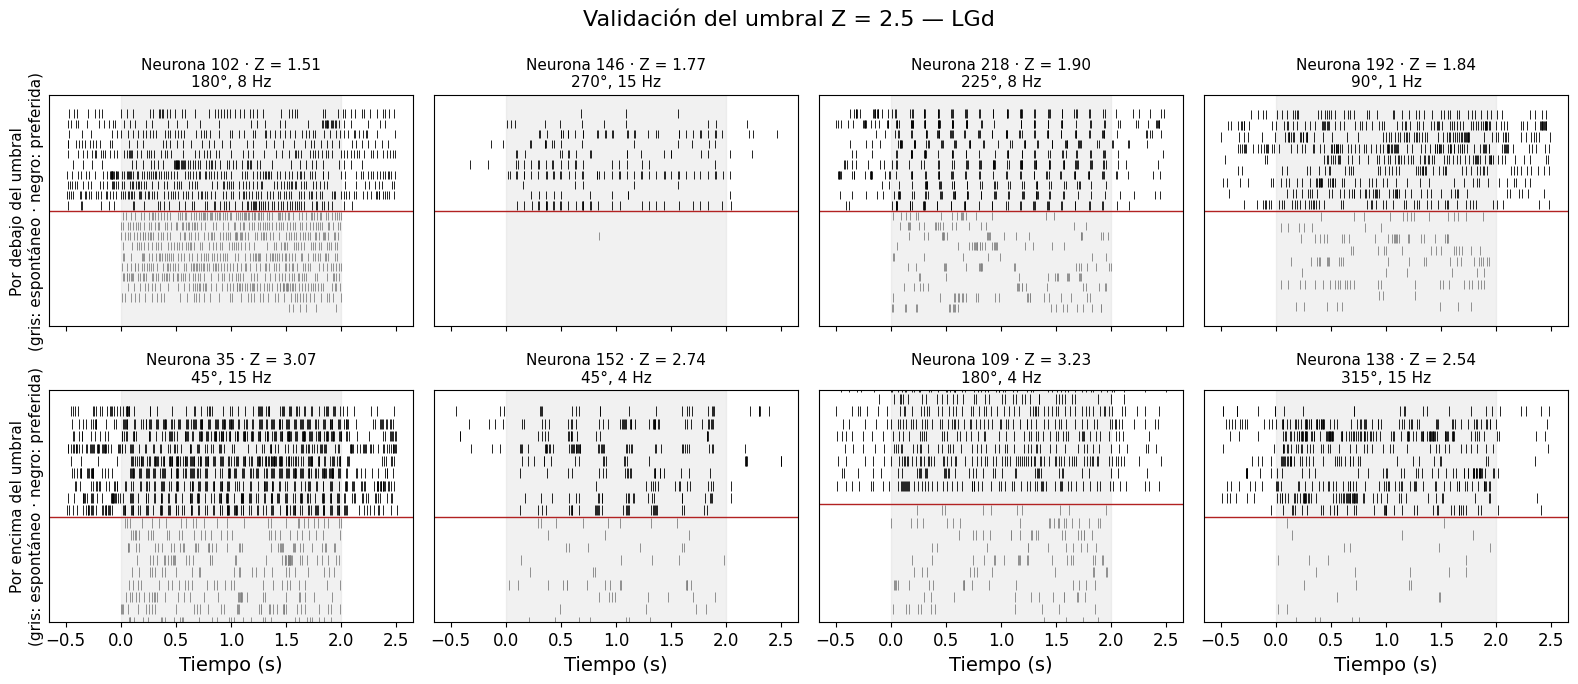

In [83]:
# ============== VALIDACIÓN DEL UMBRAL CON RASTERS ==============
N_POR_GRUPO = 4
rng_val = np.random.default_rng(0)   # semilla fija: siempre las mismas neuronas

def elegir(mask):
    candidatas = np.where(mask)[0]
    return rng_val.choice(candidatas, size=min(N_POR_GRUPO, len(candidatas)), replace=False)

debajo = elegir((zscore_preferido >= 1.5) & (zscore_preferido < umbral))
encima = elegir((zscore_preferido >= umbral) & (zscore_preferido < 3.5))

fig, axes = plt.subplots(2, N_POR_GRUPO, figsize=(16, 7), sharex=True, squeeze=False)

for fila, (grupo, nombre) in enumerate([(debajo, "Por debajo del umbral"), (encima, "Por encima del umbral")]):
    for col in range(N_POR_GRUPO):
        ax = axes[fila, col]
        if col >= len(grupo):
            ax.axis("off"); continue
        i = grupo[col]
        m_i = s_unidad == i
        t_i, ens_i = s_t[m_i], s_ensayo[m_i]

        # Ensayos de la combinación preferida (dirección + frec. temporal) de su ratón
        trials_g = ensayos_de_neurona(i, idx_gratings)
        pref = trials_g[(e_orientacion[trials_g] == pref_direccion[i]) &
                        (e_frec_temporal[trials_g] == pref_frec_temporal[i])]
        # Igual número de ensayos de espontáneo, para comparar a simple vista
        spont = ensayos_de_neurona(i, idx_spont)[:len(pref)]

        esp = [t_i[ens_i == tr] for tr in spont] + [t_i[ens_i == tr] for tr in pref]
        colores = ["gray"] * len(spont) + ["black"] * len(pref)
        ax.axvspan(0, 2, color="lightgray", alpha=0.3, zorder=0)
        ax.eventplot(esp, colors=colores, linelengths=0.8, linewidths=0.6)
        ax.axhline(len(spont) - 0.5, color="firebrick", linewidth=1)
        ax.set_title(f"Neurona {i} · Z = {zscore_preferido[i]:.2f}\n"
                     f"{pref_direccion[i]:.0f}°, {pref_frec_temporal[i]:g} Hz", fontsize=11)
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"{nombre}\n(gris: espontáneo · negro: preferida)", fontsize=11)
        if fila == 1:
            ax.set_xlabel("Tiempo (s)")

fig.suptitle(f"Validación del umbral Z = {umbral} — {NOMBRE_AREA}", fontsize=16)
ymax = max(axes[1, 0].get_ylim()[1], axes[1, 1].get_ylim()[1])
for ax in axes[1]:
    ax.set_ylim(0, ymax)
plt.tight_layout()
plt.show()

In [84]:
# Sensibilidad de las fracciones respondedoras al umbral de Z
def frac(z, u):
    z = z[~np.isnan(z)]
    return 100 * np.mean(z >= u)

sensibilidad = pd.DataFrame([{"umbral Z": u,
                              "eje común (%)": frac(zscore_preferido, u),
                              "1 Hz (%)": frac(z_1hz, u),
                              "15 Hz (%)": frac(z_15hz, u)}
                             for u in [1.5, 2.0, 2.5, 3.0]])
display(sensibilidad.round(1))

,umbral Z,eje común (%),1 Hz (%),15 Hz (%)
0,1.5,30.6,13.6,14.6
1,2.0,17.6,8.6,9.0
2,2.5,11.6,4.7,6.0
3,3.0,8.6,3.7,5.0


---
## Panel 2E · Estadística: bootstrap jerárquico, permutación y d de Cohen

**Bootstrap jerárquico en tres niveles** (10 000 réplicas), como exige el enunciado:

1. **Nivel 1 · ratones:** se sortean 5 de los 5 ratones, con reemplazo.
2. **Nivel 2 · neuronas:** dentro de cada ratón sorteado, se sortean sus neuronas con reemplazo, manteniendo el número original.
3. **Nivel 3 · ensayos:** dentro de cada neurona sorteada, se sortean con reemplazo sus ensayos de estímulo (dentro de cada dirección o combinación, para que todas sigan representadas) y sus ensayos de espontáneo. Luego se **recalcula el Z** con la condición preferida.

En cada réplica se calcula la fracción de respondedoras (Z ≥ umbral). El IC 95 % son los percentiles 2,5 y 97,5.

**Unidades de cada estadístico** (el enunciado pide declararlas en métodos):

| Estadístico | Unidad |
|---|---|
| IC 95 % | Bootstrap jerárquico ratón → neurona → ensayo |
| Valor p | Permutación pareada a nivel de **neurona**: se intercambian al azar las etiquetas 1 Hz / 15 Hz dentro de cada neurona |
| d de Cohen | Nivel de **ratón**: diferencia de fracciones por ratón dividida por su desviación estándar (d pareado, n = 5) |
| IC ingenuo | t-test que trata las 301 neuronas como independientes (ignora el ratón) |

In [85]:
# ============ PANEL 2E · PREPARACIÓN DE LOS DATOS PARA EL BOOTSTRAP ============
from scipy import stats

N_BOOT = 10_000
N_PERM = 10_000
rng_stats = np.random.default_rng(2026)   # semilla fija: resultados reproducibles

def armar_tensor(condiciones):
    """
    Organiza las tasas por ensayo (ventana tasa_dur) en arreglos rellenos para remuestrear rápido.
    condiciones: lista de (idx_ensayos, clave_de_grupo) donde clave_de_grupo[k] indica el grupo
                 (dirección o combinación) del ensayo k.
    Devuelve:
      R[neurona, condición, grupo, ensayo]  tasas evocadas (relleno con 0)
      n[neurona, condición, grupo]          número real de ensayos de cada grupo
      S[neurona, ensayo]                    tasas basales (espontáneo) de su ratón
    """
    grupos = [np.unique(clave[idx]) for idx, clave in condiciones]
    datos = []
    for i in range(n_neuronas):
        por_condicion = []
        for (idx, clave), gs in zip(condiciones, grupos):
            trials_i, tasa_i = tasa_dur(i, idx)
            k = clave[trials_i]
            por_condicion.append([tasa_i[k == g] for g in gs])
        datos.append(por_condicion)

    n_cond, G = len(condiciones), max(len(g) for g in grupos)
    T = max(len(x) for d_i in datos for c in d_i for x in c)
    R = np.zeros((n_neuronas, n_cond, G, T))
    n = np.zeros((n_neuronas, n_cond, G), dtype=int)
    for i, d_i in enumerate(datos):
        for c, lista in enumerate(d_i):
            for g, x in enumerate(lista):
                R[i, c, g, :len(x)] = x
                n[i, c, g] = len(x)

    basales = [tasa_dur(i, idx_spont)[1] for i in range(n_neuronas)]
    assert len({len(b) for b in basales}) == 1, "no todas las neuronas tienen el mismo número de ensayos espontáneos"
    return R, n, np.array(basales)

def z_preferido(R, n, S, remuestrear=False, rng=None):
    """
    Z de cada neurona en su grupo preferido, para cada condición -> arreglo (neuronas, condiciones).
    Si remuestrear=True aplica el NIVEL 3 del bootstrap: sortea con reemplazo los ensayos
    dentro de cada grupo y los ensayos de espontáneo de cada neurona.
    """
    K, n_cond, G, T = R.shape
    if remuestrear:
        j = (rng.random((K, n_cond, G, T)) * n[..., None]).astype(int)   # índices válidos 0..n-1
        R = np.take_along_axis(R, j, axis=-1)
        S = np.take_along_axis(S, rng.integers(0, S.shape[1], S.shape), axis=1)
    valido = np.arange(T) < n[..., None]
    with np.errstate(invalid="ignore", divide="ignore"):
        media = (R * valido).sum(-1) / n
        media = np.where(n > 0, media, -np.inf)              # grupos vacíos no pueden ser el máximo
        basal_media, basal_std = S.mean(1), S.std(1, ddof=1)
        z = (media.max(-1) - basal_media[:, None]) / basal_std[:, None]
    z[basal_std == 0] = np.nan
    return z

def fracciones(z):
    """Fracción de respondedoras (Z >= umbral) por condición, ignorando neuronas sin Z."""
    ok = ~np.isnan(z)
    return np.where(ok, z >= umbral, False).sum(0) / ok.sum(0)

# ---- Comparación asignada: grupos = direcciones dentro de cada frecuencia ----
R_cmp, n_cmp, S_cmp = armar_tensor([(idx_1hz, e_orientacion), (idx_15hz, e_orientacion)])

# ---- Eje común: grupos = combinaciones dirección x frec. temporal x frec. espacial ----
clave_combo = e_orientacion * 1e4 + e_frec_temporal * 100 + e_frec_espacial
R_eje, n_eje, S_eje = armar_tensor([(idx_gratings, clave_combo)])

# ---- VERIFICACIÓN: sin remuestreo, deben salir exactamente los Z calculados antes ----
z_obs_cmp = z_preferido(R_cmp, n_cmp, S_cmp)
z_obs_eje = z_preferido(R_eje, n_eje, S_eje)
assert np.allclose(z_obs_cmp[:, 0], z_1hz, equal_nan=True), "no coincide con z_1hz"
assert np.allclose(z_obs_cmp[:, 1], z_15hz, equal_nan=True), "no coincide con z_15hz"
assert np.allclose(z_obs_eje[:, 0], zscore_preferido, equal_nan=True), "no coincide con zscore_preferido"
print("Verificación OK: los arreglos reproducen z_1hz, z_15hz y zscore_preferido.")
print(f"Forma R comparación: {R_cmp.shape} | R eje común: {R_eje.shape} | S: {S_cmp.shape}")

Verificación OK: los arreglos reproducen z_1hz, z_15hz y zscore_preferido.
Forma R comparación: (301, 2, 8, 10) | R eje común: (301, 1, 40, 10) | S: (301, 150)


In [86]:
# ============ BOOTSTRAP JERÁRQUICO: ratón -> neurona -> ensayo ============
ratones = np.unique(u_raton)
neuronas_por_raton = {r: np.where(u_raton == r)[0] for r in ratones}

def bootstrap_jerarquico(R, n, S, n_boot, rng, etiqueta=""):
    """Devuelve (n_boot, condiciones) con la fracción de respondedoras de cada réplica."""
    resultados = np.empty((n_boot, R.shape[1]))
    for b in range(n_boot):
        # NIVEL 1 · ratones: 5 de 5, con reemplazo
        ratones_b = rng.choice(ratones, size=len(ratones), replace=True)
        # NIVEL 2 · neuronas: dentro de cada ratón sorteado, sus neuronas con reemplazo
        neur_b = np.concatenate([
            rng.choice(neuronas_por_raton[r], size=len(neuronas_por_raton[r]), replace=True)
            for r in ratones_b
        ])
        # NIVEL 3 · ensayos: dentro de cada neurona sorteada (se hace dentro de z_preferido)
        z_b = z_preferido(R[neur_b], n[neur_b], S[neur_b], remuestrear=True, rng=rng)
        resultados[b] = fracciones(z_b)
        if b == 0:
            print(f"[{etiqueta}] Ejemplo réplica 1 · ratones sorteados: {ratones_b}")
        if (b + 1) % 2000 == 0:
            print(f"[{etiqueta}] {b + 1}/{n_boot} réplicas")
    return resultados

boot_cmp = bootstrap_jerarquico(R_cmp, n_cmp, S_cmp, N_BOOT, rng_stats, "1 Hz vs 15 Hz")
boot_eje = bootstrap_jerarquico(R_eje, n_eje, S_eje, N_BOOT, rng_stats, "Eje común")

[1 Hz vs 15 Hz] Ejemplo réplica 1 · ratones sorteados: [761418226 715093703 715093703 760345702 750749662]
[1 Hz vs 15 Hz] 2000/10000 réplicas
[1 Hz vs 15 Hz] 4000/10000 réplicas
[1 Hz vs 15 Hz] 6000/10000 réplicas
[1 Hz vs 15 Hz] 8000/10000 réplicas
[1 Hz vs 15 Hz] 10000/10000 réplicas
[Eje común] Ejemplo réplica 1 · ratones sorteados: [760345702 750749662 756029989 760345702 760345702]
[Eje común] 2000/10000 réplicas
[Eje común] 4000/10000 réplicas
[Eje común] 6000/10000 réplicas
[Eje común] 8000/10000 réplicas
[Eje común] 10000/10000 réplicas


In [87]:
# ============ IC, VALOR p, d DE COHEN Y t-TEST INGENUO ============
ic = lambda x: np.percentile(x, [2.5, 97.5])

# ---- Valores observados ----
frac_obs = fracciones(z_obs_cmp)                 # [1 Hz, 15 Hz]
dif_obs = frac_obs[1] - frac_obs[0]
boot_dif = boot_cmp[:, 1] - boot_cmp[:, 0]

# ---- Valor p: permutación pareada a nivel de NEURONA ----
# Intercambiar al azar las etiquetas 1 Hz / 15 Hz dentro de cada neurona equivale
# a cambiar el signo de su diferencia (responde_15 - responde_1).
ok = ~np.isnan(z_obs_cmp).any(1)
resp_1 = (z_obs_cmp[ok, 0] >= umbral).astype(float)
resp_15 = (z_obs_cmp[ok, 1] >= umbral).astype(float)
dif_neurona = resp_15 - resp_1
signos = rng_stats.choice([-1, 1], size=(N_PERM, len(dif_neurona)))
dif_perm = (signos * dif_neurona).mean(1)
p_perm = (np.sum(np.abs(dif_perm) >= abs(dif_neurona.mean())) + 1) / (N_PERM + 1)

# ---- d de Cohen a nivel de RATÓN (pareado): media de la diferencia / su DE ----
frac_raton = pd.DataFrame({"raton": u_raton[ok], "r1": resp_1, "r15": resp_15}).groupby("raton").mean()
frac_raton["dif"] = frac_raton["r15"] - frac_raton["r1"]
d_cohen = frac_raton["dif"].mean() / frac_raton["dif"].std(ddof=1)

# ---- t-test INGENUO: trata las neuronas como independientes (ignora el ratón) ----
def ic_t(x):
    m, se = x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    t_crit = stats.t.ppf(0.975, len(x) - 1)
    return np.array([m - t_crit * se, m + t_crit * se])

ok_eje = ~np.isnan(z_obs_eje[:, 0])
resp_eje = (z_obs_eje[ok_eje, 0] >= umbral).astype(float)
p_t_ingenuo = stats.ttest_rel(resp_15, resp_1).pvalue

# ---- Tabla resumen ----
filas = [
    ("Eje común (rejillas vs espontáneo)", fracciones(z_obs_eje)[0], ic(boot_eje[:, 0]), ic_t(resp_eje)),
    ("1 Hz", frac_obs[0], ic(boot_cmp[:, 0]), ic_t(resp_1)),
    ("15 Hz", frac_obs[1], ic(boot_cmp[:, 1]), ic_t(resp_15)),
    ("Diferencia 15 Hz − 1 Hz", dif_obs, ic(boot_dif), ic_t(dif_neurona)),
]
resumen_2e = pd.DataFrame([{
    "medida": nombre,
    "observado (%)": 100 * obs,
    "IC95 jerárquico (%)": f"[{100*a:.1f}, {100*b:.1f}]",
    "ancho jerárquico (pp)": 100 * (b - a),
    "IC95 t-test ingenuo (%)": f"[{100*c:.1f}, {100*e:.1f}]",
    "ancho ingenuo (pp)": 100 * (e - c),
} for nombre, obs, (a, b), (c, e) in filas])
resumen_2e["jerárquico / ingenuo"] = resumen_2e["ancho jerárquico (pp)"] / resumen_2e["ancho ingenuo (pp)"]
display(resumen_2e.round(2))

print(f"\nValor p (permutación pareada, nivel neurona, {N_PERM:,} permutaciones): {p_perm:.4f}")
print(f"Valor p t-test pareado ingenuo (solo referencia): {p_t_ingenuo:.4f}")
print(f"d de Cohen (nivel ratón, pareado, n = {len(frac_raton)}): {d_cohen:.2f}")
print("\nFracciones por ratón:")
display((100 * frac_raton).round(1))

,medida,observado (%),IC95 jerárquico (%),ancho jerárquico (pp),IC95 t-test ingenuo (%),ancho ingenuo (pp),jerárquico / ingenuo
0,Eje común (rejillas vs espontáneo),11.63,"[5.0, 29.8]",24.80,"[8.0, 15.3]",7.28,3.40
1,1 Hz,4.65,"[1.4, 13.2]",11.76,"[2.3, 7.0]",4.79,2.46
2,15 Hz,5.98,"[2.5, 14.5]",11.95,"[3.3, 8.7]",5.39,2.22
3,Diferencia 15 Hz − 1 Hz,1.33,"[-2.1, 5.2]",7.28,"[-1.3, 3.9]",5.23,1.39



Valor p (permutación pareada, nivel neurona, 10,000 permutaciones): 0.4498
Valor p t-test pareado ingenuo (solo referencia): 0.3181
d de Cohen (nivel ratón, pareado, n = 5): 0.68

Fracciones por ratón:


,r1,r15,dif
raton,,,
715093703,12.2,12.2,0.0
750749662,2.4,2.4,0.0
756029989,1.7,6.8,5.1
760345702,2.7,5.4,2.7
761418226,0.0,0.0,0.0


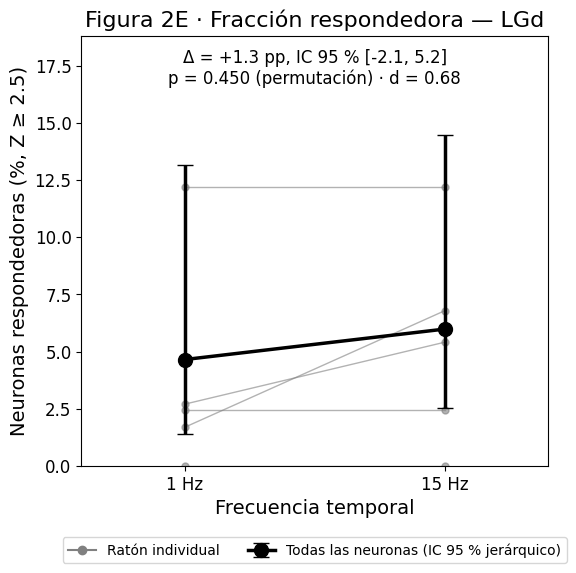

In [88]:
# ============ FIGURA 2E · PUNTOS CONECTADOS ============
fig, ax = plt.subplots(figsize=(6, 6))
x = np.array([0, 1])

# Una línea gris por ratón (su fracción en cada condición)
for _, fila in frac_raton.iterrows():
    ax.plot(x, 100 * fila[["r1", "r15"]].values, color="gray", alpha=0.6,
            marker="o", markersize=5, linewidth=1)

# Fracción de todas las neuronas, con IC 95 % del bootstrap jerárquico
ic_cond = np.array([ic(boot_cmp[:, 0]), ic(boot_cmp[:, 1])])
yerr = 100 * np.abs(ic_cond.T - frac_obs)
ax.errorbar(x, 100 * frac_obs, yerr=yerr, color="black", marker="o", markersize=10,
            linewidth=2.5, capsize=6, zorder=3, label="Todas las neuronas (IC 95 % jerárquico)")
ax.plot([], [], color="gray", marker="o", label="Ratón individual")

a, b = ic(boot_dif)
ax.text(0.5, 0.97,
        f"Δ = {100*dif_obs:+.1f} pp, IC 95 % [{100*a:.1f}, {100*b:.1f}]\n"
        f"p = {p_perm:.3f} (permutación) · d = {d_cohen:.2f}",
        transform=ax.transAxes, ha="center", va="top", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(["1 Hz", "15 Hz"])
ax.set_xlim(-0.4, 1.4)
tope = 100 * max(ic_cond.max(), frac_raton[["r1", "r15"]].values.max())
ax.set_ylim(0, tope * 1.3)   # espacio para la anotación
ax.set_xlabel("Frecuencia temporal")
ax.set_ylabel(f"Neuronas respondedoras (%, Z ≥ {umbral})")
ax.set_title(f"Figura 2E · Fracción respondedora — {NOMBRE_AREA}")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

---
## PANELES 2B Y 2C

In [89]:
# %% ======================= CELDA 1 · FUNCIONES COMUNES 2B / 2C =======================
# Nombres legibles de cada clase de estímulo
ETIQUETAS_CLASE = {
    "drifting_gratings": "Rejillas en movimiento",
    "spontaneous": "Espontáneo",
    "static_gratings": "Rejillas estáticas",
    "natural_scenes": "Escenas naturales",
    "flashes": "Destellos",
    "natural_movie_one": "Película natural",
}

# Índices de ensayos por clase (rejillas en movimiento SIN barridos en blanco)
IDX_CLASE = {c: (idx_gratings if c == "drifting_gratings" else np.where(e_clase == c)[0])
             for c in ETIQUETAS_CLASE}

# Duración típica de cada clase, para agrupar y para la ventana de conteo
DUR_CLASE = {c: float(np.median(e_dur[idx])) for c, idx in IDX_CLASE.items()}
for c, dur in DUR_CLASE.items():
    print(f"{ETIQUETAS_CLASE[c]:<24s} {len(IDX_CLASE[c]):>5d} ensayos · duración ≈ {dur:.2f} s")

def mascara_espigas_de(idx_ensayos):
    """True para cada espiga que pertenece a alguno de los ensayos de idx_ensayos."""
    sel = np.zeros(len(e_clase), dtype=bool)
    sel[idx_ensayos] = True
    return sel[s_ensayo]

def n_ensayos_por_neurona(idx_ensayos):
    """Cuántos ensayos de idx_ensayos vio cada neurona (los de su propio ratón)."""
    por_raton = pd.Series(e_raton[idx_ensayos]).value_counts()
    return por_raton.reindex(u_raton).fillna(0).values


Rejillas en movimiento    1905 ensayos · duración ≈ 2.00 s
Espontáneo                 750 ensayos · duración ≈ 2.00 s
Rejillas estáticas        1250 ensayos · duración ≈ 0.25 s
Escenas naturales         2000 ensayos · duración ≈ 0.25 s
Destellos                  750 ensayos · duración ≈ 0.25 s
Película natural            40 ensayos · duración ≈ 30.03 s


Rejillas en movimiento   ventana  -0.50 a   2.50 s · bins de 50 ms
Espontáneo               ventana   0.00 a   2.00 s · bins de 50 ms
Rejillas estáticas       ventana  -0.30 a   0.75 s · bins de 10 ms
Escenas naturales        ventana  -0.30 a   0.75 s · bins de 10 ms
Destellos                ventana  -0.50 a   1.25 s · bins de 10 ms
Película natural         ventana  -1.00 a  31.00 s · bins de 250 ms


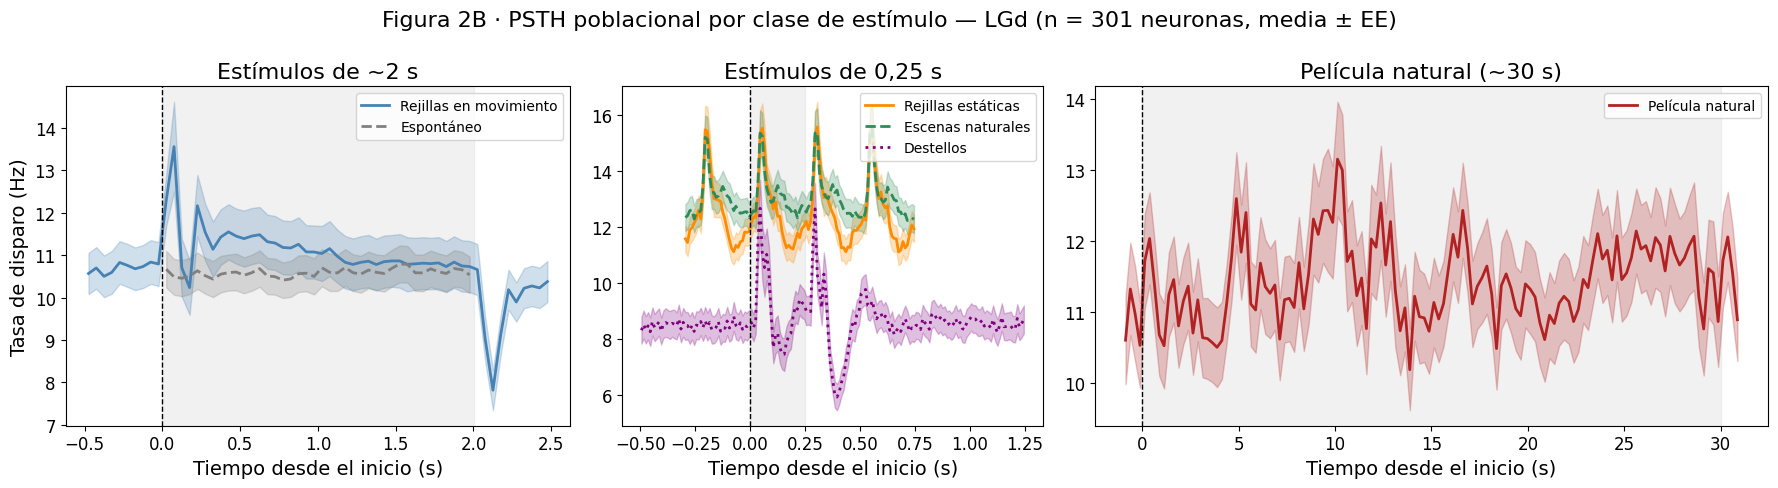

In [90]:
# %% ======================= CELDA 2 · FIGURA 2B · PSTH POBLACIONAL POR CLASE =======================
# Regla del enunciado: solo se agrupan estímulos con la MISMA duración.
#   ~2 s   : rejillas en movimiento (sin blancos) y espontáneo
#   0,25 s : rejillas estáticas, escenas naturales y destellos
#   ~30 s  : película natural (sola)
# Cada línea: PSTH promediado sobre ensayos (de su ratón) y luego sobre neuronas,
# con sombreado de error estándar entre neuronas.

GRUPOS_2B = [
    # (título,                       clases,                                              bin en s)
    ("Estímulos de ~2 s",            ["drifting_gratings", "spontaneous"],                  0.05),
    ("Estímulos de 0,25 s",          ["static_gratings", "natural_scenes", "flashes"],      0.01),
    ("Película natural (~30 s)",     ["natural_movie_one"],                                 0.25),
]
ESTILO_2B = {  # color + tipo de línea, para que se distingan también en blanco y negro
    "drifting_gratings": ("steelblue", "-"),   "spontaneous": ("gray", "--"),
    "static_gratings": ("darkorange", "-"),    "natural_scenes": ("seagreen", "--"),
    "flashes": ("purple", ":"),                "natural_movie_one": ("firebrick", "-"),
}

def rango_temporal(clase, bin_s):
    """Ventana de tiempo que cubre el archivo para esta clase (según sus espigas)."""
    t = s_t[mascara_espigas_de(IDX_CLASE[clase])]
    return np.round(t.min() / bin_s) * bin_s, np.round(t.max() / bin_s) * bin_s

def psth_poblacional(idx_ensayos, bins):
    """PSTH medio sobre neuronas y su error estándar entre neuronas (Hz)."""
    m = mascara_espigas_de(idx_ensayos) & (s_t >= bins[0]) & (s_t < bins[-1])
    H, _, _ = np.histogram2d(s_unidad[m], s_t[m],
                             bins=[np.arange(n_neuronas + 1) - 0.5, bins])  # neuronas x bins
    n_tr = n_ensayos_por_neurona(idx_ensayos)
    validas = n_tr > 0
    tasa = H[validas] / (n_tr[validas, None] * np.diff(bins))              # Hz por neurona
    return tasa.mean(axis=0), tasa.std(axis=0, ddof=1) / np.sqrt(validas.sum())

fig, axes = plt.subplots(1, len(GRUPOS_2B), figsize=(18, 5),
                         gridspec_kw={"width_ratios": [1.2, 1, 1.6]})

for ax, (titulo, clases, bin_s) in zip(axes, GRUPOS_2B):
    for c in clases:
        # Cada clase se grafica en su propio rango: el espontáneo, por ejemplo, solo trae 0 a 2 s
        t_ini, t_fin = rango_temporal(c, bin_s)
        bins = np.arange(t_ini, t_fin + bin_s / 2, bin_s)
        centros = bins[:-1] + bin_s / 2
        print(f"{ETIQUETAS_CLASE[c]:<24s} ventana {t_ini:6.2f} a {t_fin:6.2f} s · bins de {bin_s*1000:.0f} ms")

        media, sem = psth_poblacional(IDX_CLASE[c], bins)
        color, estilo = ESTILO_2B[c]
        ax.plot(centros, media, color=color, linestyle=estilo, linewidth=2, label=ETIQUETAS_CLASE[c])
        ax.fill_between(centros, media - sem, media + sem, color=color, alpha=0.25)

    dur_estimulo = max(DUR_CLASE[c] for c in clases if c != "spontaneous")
    ax.axvspan(0, dur_estimulo, color="lightgray", alpha=0.3, zorder=0)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel("Tiempo desde el inicio (s)")
    ax.legend(loc="upper right", fontsize=10)

axes[0].set_ylabel("Tasa de disparo (Hz)")
fig.suptitle(f"Figura 2B · PSTH poblacional por clase de estímulo — {NOMBRE_AREA} "
             f"(n = {n_neuronas} neuronas, media ± EE)", fontsize=16)
plt.tight_layout()
plt.show()


,estímulo,neuronas,respondedoras (Z ≥ 2.5),%,Z mediana
0,Movimiento (2.0 s),301,35,11.6,0.93
1,Estáticas (0.25 s),301,30,10.0,1.11


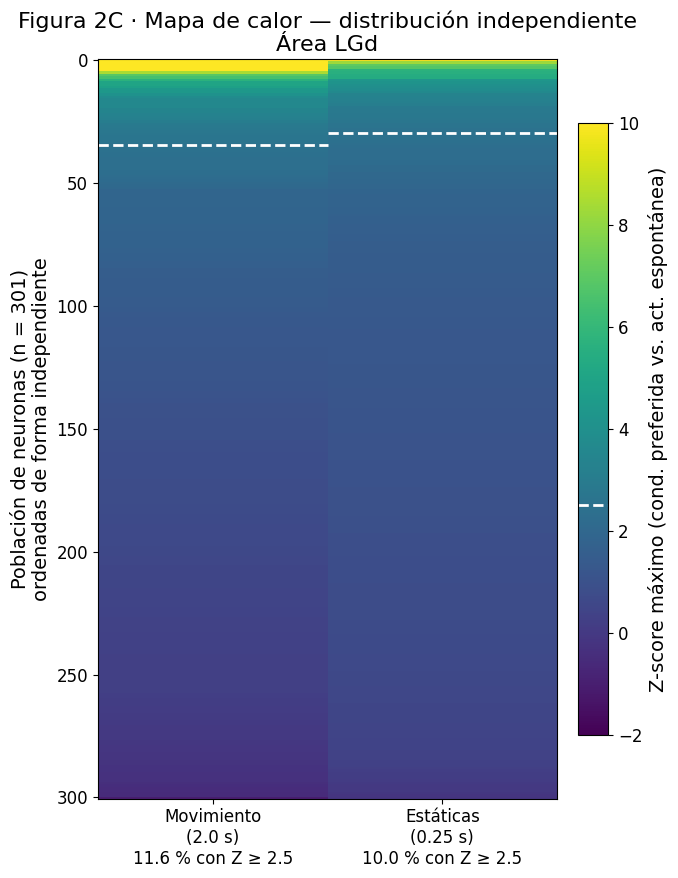

In [91]:
# %% ======================= CELDA 3 · FIGURA 2C · MAPA DE CALOR (formato del profesor) =======================
# Dos columnas: rejillas en movimiento (2 s) y rejillas estáticas (0,25 s).
# Valor: Z-score MÁXIMO = condición preferida de cada neurona vs. su actividad espontánea.
#   - Movimiento: el mismo zscore_preferido del eje común (dirección x frec. temporal x frec. espacial).
#   - Estáticas: combinación preferida orientación x frec. espacial (30 combinaciones, ~8 ensayos
#     por combinación y ratón). La fase se promedia: con 4 fases habría 120 combinaciones de ~2
#     ensayos cada una, y el máximo sobre tantas medias tan ruidosas inflaría el Z.
# Basal: ventanas del espontáneo de la MISMA duración que el estímulo (2 s y 0,25 s).
# Cada columna se ordena de forma INDEPENDIENTE (de mayor a menor), como en la figura de
# referencia: una fila NO es la misma neurona en las dos columnas.

def basal_en_ventanas(w):
    """Media y DE de la tasa basal de cada neurona en ventanas de w s del espontáneo."""
    n_sub = max(1, int(np.floor(2.0 / w + 1e-9)))          # ventanas por trozo de 2 s
    m = mascara_espigas_de(idx_spont) & (s_t >= 0) & (s_t < n_sub * w)
    clave = s_ensayo[m] * n_sub + np.floor(s_t[m] / w).astype(int)
    conteo_sub = pd.DataFrame({"unidad": s_unidad[m], "clave": clave}).groupby(["unidad", "clave"]).size()

    media, de = np.full(n_neuronas, np.nan), np.full(n_neuronas, np.nan)
    for i in range(n_neuronas):
        trials_i = ensayos_de_neurona(i, idx_spont)
        claves_i = (trials_i[:, None] * n_sub + np.arange(n_sub)).ravel()
        tasas = conteo_sub.reindex(pd.MultiIndex.from_product([[i], claves_i]), fill_value=0).values / w
        media[i], de[i] = tasas.mean(), tasas.std(ddof=1)
    return media, de

# ---- Z preferido de rejillas ESTÁTICAS (orientación x frec. espacial) ----
idx_estaticas = IDX_CLASE["static_gratings"]
basal_media_025, basal_de_025 = basal_en_ventanas(round(DUR_CLASE["static_gratings"], 2))

zscore_pref_estaticas = np.full(n_neuronas, np.nan)
pref_ori_estaticas = np.full(n_neuronas, np.nan)
pref_fe_estaticas = np.full(n_neuronas, np.nan)

for i in range(n_neuronas):
    if not basal_de_025[i] > 0:
        continue
    trials_i, tasa_i = tasa_dur(i, idx_estaticas)          # ventana 0 a e_dur (~0,25 s)
    combo = pd.DataFrame({"orientacion": e_orientacion[trials_i],
                          "frec_espacial": e_frec_espacial[trials_i],
                          "tasa": tasa_i})
    combo = combo.dropna(subset=["orientacion", "frec_espacial"])   # por si hay blancos
    medias = combo.groupby(["orientacion", "frec_espacial"])["tasa"].mean()
    z = (medias - basal_media_025[i]) / basal_de_025[i]
    zscore_pref_estaticas[i] = z.max()
    pref_ori_estaticas[i], pref_fe_estaticas[i] = z.idxmax()

# ---- Matriz del panel: columna 0 = movimiento, columna 1 = estáticas ----
COLUMNAS_2C = [(f"Movimiento\n({DUR_CLASE['drifting_gratings']:.1f} s)", zscore_preferido),
               (f"Estáticas\n({DUR_CLASE['static_gratings']:.2f} s)", zscore_pref_estaticas)]

# Cada columna se ordena por separado, de mayor a menor (NaN al final)
Z_2C = np.column_stack([np.sort(z[~np.isnan(z)])[::-1].tolist() + [np.nan] * int(np.isnan(z).sum())
                        for _, z in COLUMNAS_2C])

resumen_2C = pd.DataFrame({
    "estímulo": [n.replace("\n", " ") for n, _ in COLUMNAS_2C],
    "neuronas": [int(np.sum(~np.isnan(z))) for _, z in COLUMNAS_2C],
    f"respondedoras (Z ≥ {umbral})": [int(np.sum(z >= umbral)) for _, z in COLUMNAS_2C],
    "%": [round(100 * np.mean(z[~np.isnan(z)] >= umbral), 1) for _, z in COLUMNAS_2C],
    "Z mediana": [round(np.nanmedian(z), 2) for _, z in COLUMNAS_2C],
})
display(resumen_2C)

# ---- Figura ----
VMIN_2C, VMAX_2C = -2, 10          # mismo rango de color que la figura de referencia (se recorta fuera)
fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(Z_2C, aspect="auto", cmap="viridis", interpolation="nearest",
               vmin=VMIN_2C, vmax=VMAX_2C)

# Marca, en cada columna, dónde cruza el umbral (cada columna tiene su propio orden)
for j, (_, z) in enumerate(COLUMNAS_2C):
    n_resp = int(np.sum(z >= umbral))
    ax.hlines(n_resp - 0.5, j - 0.5, j + 0.5, color="white", linewidth=2, linestyle="--")

ax.set_xticks(range(len(COLUMNAS_2C)))
ax.set_xticklabels([f"{n}\n{p:.1f} % con Z ≥ {umbral}"
                    for (n, _), p in zip(COLUMNAS_2C, resumen_2C["%"])], fontsize=12)
ax.set_ylabel(f"Población de neuronas (n = {n_neuronas})\nordenadas de forma independiente")
cbar = fig.colorbar(im, ax=ax, fraction=0.06, pad=0.04)
cbar.ax.axhline(umbral, color="white", linewidth=2, linestyle="--")   # umbral en la barra
cbar.set_label("Z-score máximo (cond. preferida vs. act. espontánea)")
ax.set_title(f"Figura 2C · Mapa de calor — distribución independiente\nÁrea {NOMBRE_AREA}")
plt.tight_layout()
plt.show()

---
## Punto extra: histograma de frecuencia temporal preferida


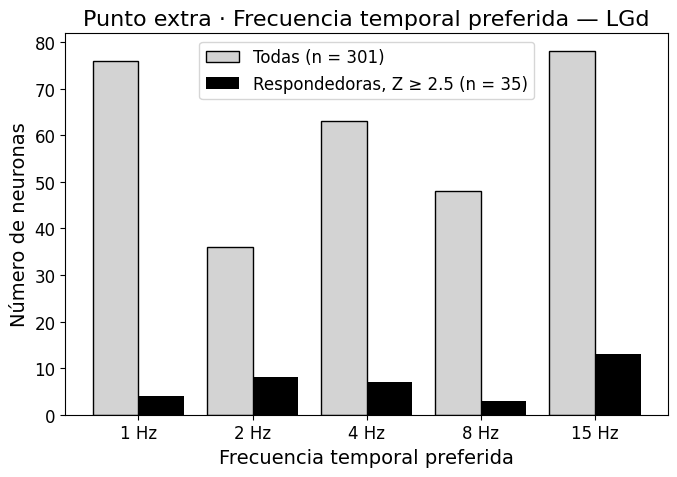

,FT (Hz),todas,respondedoras
0,1,76,4
1,2,36,8
2,4,63,7
3,8,48,3
4,15,78,13


In [92]:
# PUNTO EXTRA · Histograma de la frecuencia temporal preferida por neurona
# pref_frec_temporal (Paso 4) = frecuencia de la combinación con mayor Z de cada neurona,
# es decir, el máximo de cada fila de la matriz neurona x frecuencia temporal.
FT = [1, 2, 4, 8, 15]
resp = zscore_preferido >= umbral
conteo_todas = [int(np.sum(pref_frec_temporal == f)) for f in FT]
conteo_resp = [int(np.sum((pref_frec_temporal == f) & resp)) for f in FT]

x = np.arange(len(FT))
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - 0.2, conteo_todas, width=0.4, color="lightgray", edgecolor="black",
       label=f"Todas (n = {int(np.sum(~np.isnan(pref_frec_temporal)))})")
ax.bar(x + 0.2, conteo_resp, width=0.4, color="black",
       label=f"Respondedoras, Z ≥ {umbral} (n = {int(resp.sum())})")
ax.set_xticks(x)
ax.set_xticklabels([f"{f} Hz" for f in FT])
ax.set_xlabel("Frecuencia temporal preferida")
ax.set_ylabel("Número de neuronas")
ax.set_title(f"Punto extra · Frecuencia temporal preferida — {NOMBRE_AREA}")
ax.legend()
plt.tight_layout()
plt.show()
display(pd.DataFrame({"FT (Hz)": FT, "todas": conteo_todas, "respondedoras": conteo_resp}))

In [93]:
# Sensibilidad de las fracciones respondedoras al umbral de Z
def frac(z, u):
    z = z[~np.isnan(z)]
    return 100 * np.mean(z >= u)

sensibilidad = pd.DataFrame([{"umbral Z": u,
                              "eje común (%)": frac(zscore_preferido, u),
                              "1 Hz (%)": frac(z_1hz, u),
                              "15 Hz (%)": frac(z_15hz, u)}
                             for u in [1.5, 2.0, 2.5, 3.0]])
sensibilidad["15 Hz − 1 Hz (pp)"] = sensibilidad["15 Hz (%)"] - sensibilidad["1 Hz (%)"]
display(sensibilidad.round(1))

,umbral Z,eje común (%),1 Hz (%),15 Hz (%),15 Hz − 1 Hz (pp)
0,1.5,30.6,13.6,14.6,1.0
1,2.0,17.6,8.6,9.0,0.3
2,2.5,11.6,4.7,6.0,1.3
3,3.0,8.6,3.7,5.0,1.3


# Declaración de uso de IA

Usamos un modelo de lenguaje (Claude) para generar y revisar el código de varios pasos, dándole primero la estructura del archivo y un párrafo de incongruencias que habíamos detectado a mano. Errores que detectamos y corregimos: (1) el código calculaba la fracción del eje común promediando todas las combinaciones de rejillas (2,0 %) en lugar de usar la condición preferida (11,6 %); (2) la comparación 1 vs 15 Hz usaba una ventana de 0,5 s, que cubre solo medio ciclo a 1 Hz y sesgaba el resultado a favor de 15 Hz; (3) varias celdas redefinían las mismas variables con ventanas distintas, y una incluía los barridos en blanco, así que el resultado dependía del orden de ejecución. Verificamos cada paso con los controles del enunciado (número de neuronas, tasas medianas y reproducción de los Z) y comprobamos que el bootstrap remuestreara los ratones.